In [2]:
# %pip install numpy==1.26.4
# %pip install catboost
from catboost import CatBoostRegressor

In [3]:
import pandas as pd

In [6]:
# %pip install scikit-learn
from sklearn.model_selection import train_test_split

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [102]:
df = pd.read_csv("df_merged_cleaned_highest_corr.csv")

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [104]:
X = df.drop(columns=['Цена на арматуру'])
y = df['Цена на арматуру']
X['rolling_mean'] = y.rolling(window=3).mean()

In [105]:
# Разделение на обучающие и тестовые наборы
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [106]:
# Обучение модели CatBoost
model = CatBoostRegressor(iterations=10000, learning_rate=0.03, depth=6, loss_function='MAE', verbose=1, early_stopping_rounds=100)
model.fit(X_train, y_train)

0:	learn: 6519.7865530	total: 2.6ms	remaining: 26s
1:	learn: 6381.7885444	total: 4.21ms	remaining: 21s
2:	learn: 6202.8125941	total: 6.13ms	remaining: 20.4s
3:	learn: 6020.7523480	total: 8.38ms	remaining: 20.9s
4:	learn: 5893.8516566	total: 9.9ms	remaining: 19.8s
5:	learn: 5752.7456642	total: 12.5ms	remaining: 20.9s
6:	learn: 5636.1201188	total: 14.6ms	remaining: 20.8s
7:	learn: 5527.4585776	total: 16.7ms	remaining: 20.9s
8:	learn: 5388.0926931	total: 18.8ms	remaining: 20.9s
9:	learn: 5235.4136779	total: 20.9ms	remaining: 20.9s
10:	learn: 5095.0763770	total: 24.9ms	remaining: 22.6s
11:	learn: 4997.9662077	total: 26.5ms	remaining: 22.1s
12:	learn: 4890.3143017	total: 28.1ms	remaining: 21.6s
13:	learn: 4781.4247379	total: 29.6ms	remaining: 21.1s
14:	learn: 4673.1560610	total: 30.9ms	remaining: 20.6s
15:	learn: 4559.6277291	total: 32.2ms	remaining: 20.1s
16:	learn: 4457.8696562	total: 33.3ms	remaining: 19.6s
17:	learn: 4349.9928392	total: 34.5ms	remaining: 19.2s
18:	learn: 4239.4130777	to

In [107]:
# Прогнозирование на тестовой выборке
predictions = model.predict(X_test)

In [108]:
from math import sqrt
# Оценка модели
mae = mean_absolute_error(y_test, predictions)
print(f"MAE score: {mae}")
print('R2 score:', r2_score(y_test, predictions))
print('RMSE score:', sqrt(mean_squared_error(y_test, predictions)))

MAE score: 4441.248112969628
R2 score: 0.7822508998355381
RMSE score: 5341.534306275336


In [15]:
# %pip install matplotlib

import matplotlib.pyplot as plt

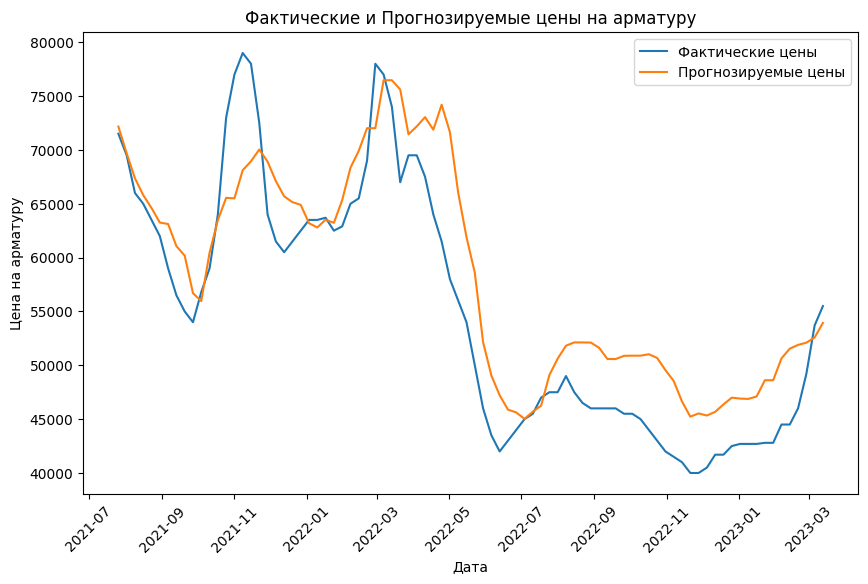

In [109]:
# Визуализация фактических и предсказанных цен
plt.figure(figsize=(10, 6))
plt.plot(df["Date"].iloc[-len(y_test):], y_test, label="Фактические цены")
plt.plot(df["Date"].iloc[-len(y_test):], predictions, label="Прогнозируемые цены")
plt.legend()
plt.xlabel("Дата")
plt.ylabel("Цена на арматуру")
plt.title("Фактические и Прогнозируемые цены на арматуру")
plt.xticks(rotation=45)
plt.show()

In [15]:
import pickle
with open('CatBoost_model.pkl', 'wb') as f: pickle.dump(model, f)

Для сравнения XGB

In [144]:
Xgb = X
Xgb['rolling_mean'] = y.rolling(window=3).mean()

In [145]:
Xgb_train, Xgb_test, ygb_train, ygb_test = train_test_split(Xgb, y, test_size=0.2, shuffle=False)

In [146]:
Xgb_train = Xgb_train.drop('Date', axis=1)
Xgb_test = Xgb_test.drop('Date', axis=1)

In [140]:
# %pip install xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from math import sqrt

In [147]:
# Определяем модель
xgb_model = XGBRegressor()

# Подгоняем модель на данных
xgb_model.fit(Xgb_train, ygb_train)

# Прогнозируем на тестовых данных
ygb_pred = xgb_model.predict(Xgb_test)

# Оцениваем модель
mae = mean_absolute_error(ygb_test, ygb_pred)
r2 = r2_score(ygb_test, ygb_pred)
rmse = sqrt(mean_squared_error(ygb_test, ygb_pred))

print(f"MAE score: {mae}")
print(f"R2 score: {r2}")
print(f"RMSE score: {rmse}")

MAE score: 2777.2588571947676
R2 score: 0.8891927614485755
RMSE score: 3810.411712631434


In [149]:
Xgb_test.head(1)

,"Лом_3А, РФ CPT ж/д Южный ФО, руб./т, без НДС","Лом_3А, РФ CPT ж/д Центральный ФО, руб./т, без НДС","Лом_3А, РФ FCA ж/д респ. Татарстан, руб./т, без НДС","Лом_3А, РФ FCA ж/д Московский регион, руб./т, без НДС","Лом_3А, РФ CPT ж/д Уральский ФО, руб./т, без НДС","Чугун_CFR Турция, $/т",rolling_mean
342,26272.0,26161.0,24725.0,24714.0,26726.0,637.5,72500.0


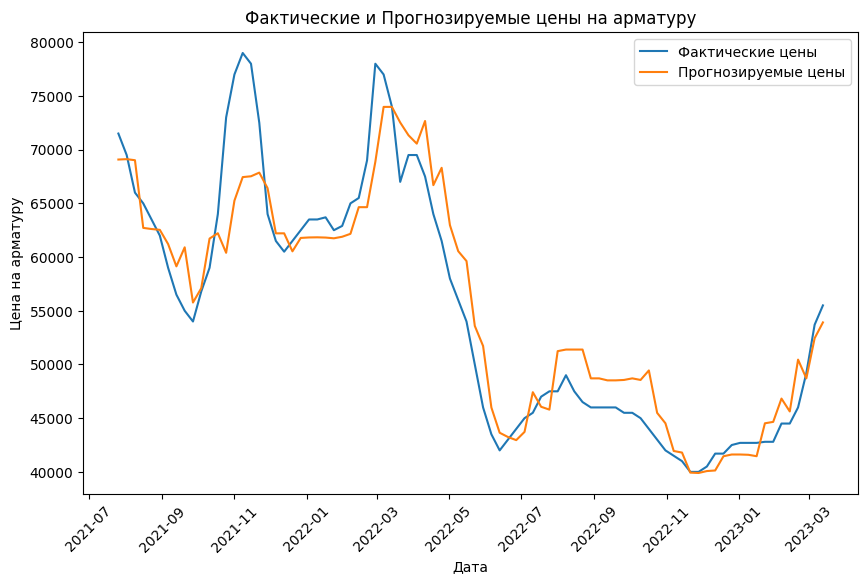

In [148]:
# Визуализация фактических и предсказанных цен
plt.figure(figsize=(10, 6))
plt.plot(df["Date"].iloc[-len(y_test):], y_test, label="Фактические цены")
plt.plot(df["Date"].iloc[-len(y_test):], ygb_pred, label="Прогнозируемые цены")
plt.legend()
plt.xlabel("Дата")
plt.ylabel("Цена на арматуру")
plt.title("Фактические и Прогнозируемые цены на арматуру")
plt.xticks(rotation=45)
plt.show()

In [150]:
import pickle
with open('XGBoost_model.pkl', 'wb') as f: pickle.dump(model, f)

Поиск параметров (не удачный)

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

# Определяем модель
catboost_model = CatBoostRegressor(verbose=0)

# Определяем сетку параметров для поиска
param_grid = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

# Определяем метрику для оценки
scorer = make_scorer(mean_absolute_error, greater_is_better=False)

# Создаем GridSearchCV объект
grid_search = GridSearchCV(estimator=catboost_model, param_grid=param_grid, scoring=scorer, cv=5)

# Подгоняем модель на данных
grid_search.fit(X_train, y_train)

# Выводим лучшие параметры
print("Лучшие параметры: ", grid_search.best_params_)

# Оцениваем модель на тестовых данных
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

Лучшие параметры:  {'depth': 4, 'iterations': 300, 'l2_leaf_reg': 5, 'learning_rate': 0.01}


In [121]:
print(xgb_model.get_booster().feature_names)  # Для XGBoost

['Лом_3А, РФ CPT ж/д Южный ФО, руб./т, без НДС', 'Лом_3А, РФ CPT ж/д Центральный ФО, руб./т, без НДС', 'Лом_3А, РФ FCA ж/д респ. Татарстан, руб./т, без НДС', 'Лом_3А, РФ FCA ж/д Московский регион, руб./т, без НДС', 'Лом_3А, РФ CPT ж/д Уральский ФО, руб./т, без НДС', 'Чугун_CFR Турция, $/т', 'rolling_mean']
